# 04 — Modeling and Evaluation

In this notebook, we train classification models to predict customer churn and compare their performance.

In this notebook, we will:
- Build a simple baseline
- Train a few classification models
- Evaluate them with metrics beyond accuracy
- Compare results and choose the most promising model
- Save the best model for future use

Because the target is imbalanced, we will pay special attention to:
- precision
- recall
- F1-score
- ROC-AUC
- confusion matrix

In [1]:
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')

In [2]:
data_dir = Path('../data/processed')
models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

X_train = pd.read_csv(data_dir / 'X_train_processed.csv')
X_test = pd.read_csv(data_dir / 'X_test_processed.csv')
y_train = pd.read_csv(data_dir / 'y_train.csv').squeeze('columns')
y_test = pd.read_csv(data_dir / 'y_test.csv').squeeze('columns')

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (8000, 11)
X_test shape: (2000, 11)
y_train shape: (8000,)
y_test shape: (2000,)


## 1. Check the target distribution again

In [4]:
print('Train target distribution (%):')
print(y_train.value_counts(normalize=True).mul(100).round(2))
print('Test target distribution (%):')
print(y_test.value_counts(normalize=True).mul(100).round(2))

Train target distribution (%):
Exited
0   79.6200
1   20.3800
Name: proportion, dtype: float64
Test target distribution (%):
Exited
0   79.6500
1   20.3500
Name: proportion, dtype: float64


## 2. Define an evaluation function

This function helps us compare all models in a consistent way.

In [5]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    results = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
    }

    if y_proba is not None:
        results['ROC-AUC'] = roc_auc_score(y_test, y_proba)
    else:
        results['ROC-AUC'] = np.nan

    return model, results, y_pred, y_proba

## 3. Define the models

We include:
- **DummyClassifier** as a baseline
- **Logistic Regression** as a simple linear model
- **Decision Tree** as an interpretable non-linear model
- **Random Forest** as a stronger ensemble model
- **Gradient Boosting** as another powerful tree-based model

For some models, `class_weight='balanced'` is used to give more importance to the minority class.

In [6]:
models = {
    'Dummy (Most Frequent)': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_split=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

## 4. Train and evaluate all models

In [7]:
results_list = []
trained_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    trained_model, result, y_pred, y_proba = evaluate_model(
        model, X_train, X_test, y_train, y_test, name
    )

    trained_models[name] = trained_model
    predictions[name] = y_pred
    probabilities[name] = y_proba
    results_list.append(result)

results_df = pd.DataFrame(results_list).sort_values(by='F1-score', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
3,Random Forest,0.8230,0.5499,0.7174,0.6226,0.8668
4,Gradient Boosting,0.8700,0.7928,0.4889,0.6049,0.8708
2,Decision Tree,0.7700,0.4607,0.7641,0.5749,0.8379
1,Logistic Regression,0.7140,0.3878,0.7002,0.4991,0.7772
0,Dummy (Most Frequent),0.7965,0.0000,0.0000,0.0000,0.5000


## 5. Visual comparison of model performance

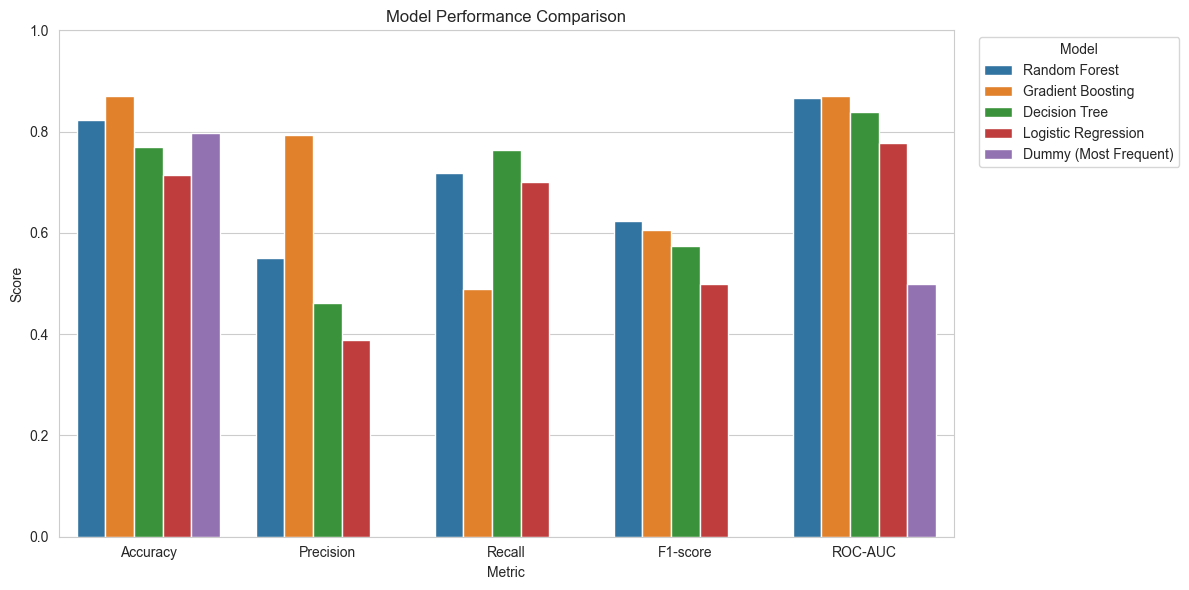

In [8]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']

results_melted = results_df.melt(
    id_vars='Model',
    value_vars=metrics_to_plot,
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x='Metric', y='Score', hue='Model')
plt.title('Model Performance Comparison')
plt.ylim(0, 1)
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 6. Inspect confusion matrices

Confusion matrices are especially useful here because they show how well each model detects churned customers (`Exited = 1`).

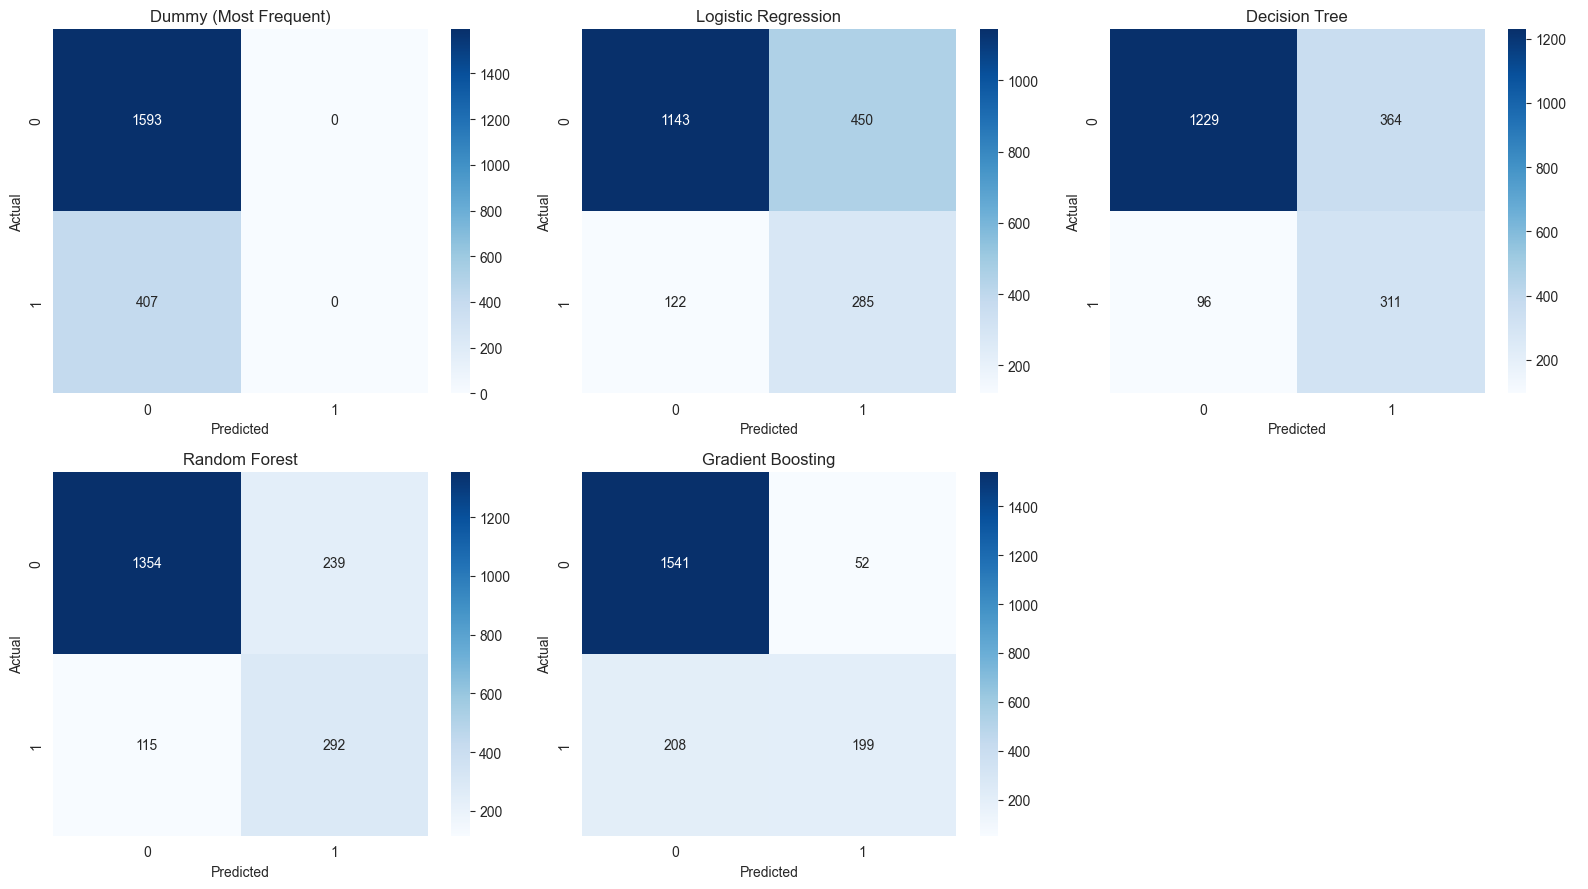

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

for i in range(len(predictions), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()